In [ ]:
!pip install pycocotools
!git clone https://github.com/bencejdanko/sign-language-translation
import sys
sys.path.append("./sign-language-translation/sam-3d-body")

In [14]:
# Instructions from INSTALL.md
# takes 5 mins
!pip install -q pytorch-lightning pyrender opencv-python yacs scikit-image einops timm dill pandas rich hydra-core hydra-submitit-launcher hydra-colorlog pyrootutils webdataset chump networkx==3.2.1 roma joblib seaborn wandb appdirs appnope ffmpeg cython jsonlines pytest xtcocotools loguru optree fvcore black pycocotools tensorboard huggingface_hub
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git@a1ce2f9' --no-build-isolation --no-deps

  Preparing metadata (setup.py) ... done


In [ ]:
import importlib.util
import sys

spec = importlib.util.spec_from_file_location("sam_utils", "./sign-language-translation/sam-3d-body/notebook/utils.py")
sam_utils = importlib.util.module_from_spec(spec)
sys.modules["sam_utils"] = sam_utils
spec.loader.exec_module(sam_utils)

setup_sam_3d_body = sam_utils.setup_sam_3d_body

In [16]:
import json
import torch
import cv2
from datasets import load_dataset
from IPython.display import Video, display

dataset = load_dataset("bdanko/how2sign-rgb-front-clips", streaming=True)
train_stream = iter(dataset["train"])
sample = next(train_stream)

if isinstance(sample["json"], dict) and "bytes" in sample["json"]:
    metadata = json.loads(sample["json"]["bytes"].decode("utf-8"))
else:
    metadata = sample["json"]

video_path = "/tmp/test_stream.mp4"
with open(video_path, "wb") as f:
    f.write(sample["mp4"])

display(Video(video_path, embed=True, width=600))

Resolving data files:   0%|          | 0/32 [00:00<?, ?it/s]

In [22]:
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')
!hf auth login --token {HF_TOKEN}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

estimator = setup_sam_3d_body(
    hf_repo_id="facebook/sam-3d-body-dinov3",
    detector_name=None,
    segmentor_name=None,
    fov_name=None
)

Loading SAM 3D Body model from facebook/sam-3d-body-dinov3...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading SAM 3D Body model...


Using cache found in /root/.cache/torch/hub/facebookresearch_dinov3_main

missing keys in source state_dict: backbone.encoder.mask_token, head_pose.hand_pose_comps_ori, head_pose.mhr.face_expressions_model.shape_vectors, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_indices, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.0.sparse_weight, head_pose.mhr.pose_correctives_model.pose_dirs_predictor.2.weight, head_pose.mhr.character_torch.skeleton.joint_translation_offsets, head_pose.mhr.character_torch.skeleton.joint_prerotations, head_pose.mhr.character_torch.skeleton.pmi, head_pose.mhr.character_torch.skeleton.joint_parents, head_pose.mhr.character_torch.mesh.rest_vertices, head_pose.mhr.character_torch.mesh.faces, head_pose.mhr.character_torch.mesh.texcoords, head_pose.mhr.character_torch.mesh.texcoord_faces, head_pose.mhr.character_torch.parameter_transform.parameter_transform, head_pose.mhr.character_torch.parameter_transform.pose_parameters, head_pose.mhr

No human detector is used...
Mask-condition inference is not supported...
No FOV estimator... Using the default FOV!
Setup complete!
  Human detector: ✗ (will use full image or manual bbox)
  Human segmentor: ✗ (mask inference disabled)
  FOV estimator: ✗ (will use default FOV)


In [23]:
import sys
import torch
import cv2

vidcap = cv2.VideoCapture(video_path)
success, image = vidcap.read()

if success:
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with torch.inference_mode():
        outputs = estimator.process_one_image(image_rgb)

        detection = outputs[0] if isinstance(outputs, list) else outputs

        print(f"Top-level keys: {list(detection.keys())}\n")

        for k, v in detection.items():
            if isinstance(v, torch.Tensor):
                print(f"[{k}] Tensor | Shape: {list(v.shape)}")
            elif isinstance(v, dict):
                print(f"[{k}] Dictionary | Keys: {list(v.keys())}")
                for sub_k, sub_v in v.items():
                    if isinstance(sub_v, torch.Tensor):
                        print(f"  -> [{sub_k}] Tensor | Shape: {list(sub_v.shape)}")
                    else:
                        print(f"  -> [{sub_k}] {type(sub_v)}")
            else:
                print(f"[{k}] {type(v)}")

vidcap.release()

####### Please make sure the input image is in RGB format
Top-level keys: ['bbox', 'focal_length', 'pred_keypoints_3d', 'pred_keypoints_2d', 'pred_vertices', 'pred_cam_t', 'pred_pose_raw', 'global_rot', 'body_pose_params', 'hand_pose_params', 'scale_params', 'shape_params', 'expr_params', 'mask', 'pred_joint_coords', 'pred_global_rots', 'mhr_model_params', 'lhand_bbox', 'rhand_bbox']

[bbox] <class 'numpy.ndarray'>
[focal_length] <class 'numpy.float32'>
[pred_keypoints_3d] <class 'numpy.ndarray'>
[pred_keypoints_2d] <class 'numpy.ndarray'>
[pred_vertices] <class 'numpy.ndarray'>
[pred_cam_t] <class 'numpy.ndarray'>
[pred_pose_raw] <class 'numpy.ndarray'>
[global_rot] <class 'numpy.ndarray'>
[body_pose_params] <class 'numpy.ndarray'>
[hand_pose_params] <class 'numpy.ndarray'>
[scale_params] <class 'numpy.ndarray'>
[shape_params] <class 'numpy.ndarray'>
[expr_params] <class 'numpy.ndarray'>
[mask] <class 'NoneType'>
[pred_joint_coords] <class 'numpy.ndarray'>
[pred_global_rots] <class 'n

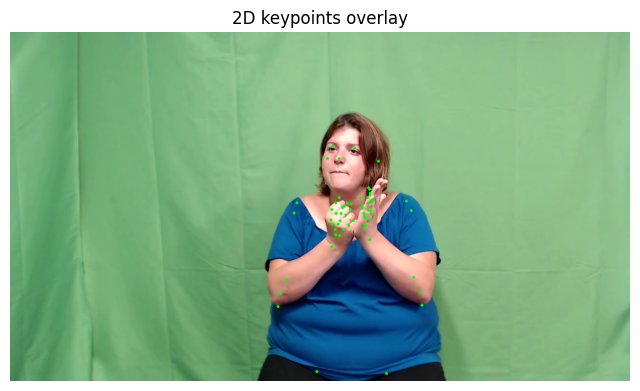

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_keypoints_2d(image_rgb, keypoints_2d, radius=3):
    img = image_rgb.copy()
    kpts = np.asarray(keypoints_2d)

    # handle shapes like (K,2) or (1,K,2)
    if kpts.ndim == 3:
        kpts = kpts[0]

    for pt in kpts:
        if len(pt) >= 2:
            x, y = float(pt[0]), float(pt[1])
            if np.isfinite(x) and np.isfinite(y):
                cv2.circle(img, (int(x), int(y)), radius, (0, 255, 0), -1)

    return img

overlay = draw_keypoints_2d(image_rgb, detection["pred_keypoints_2d"])
plt.figure(figsize=(8, 8))
plt.imshow(overlay)
plt.axis("off")
plt.title("2D keypoints overlay")
plt.show()

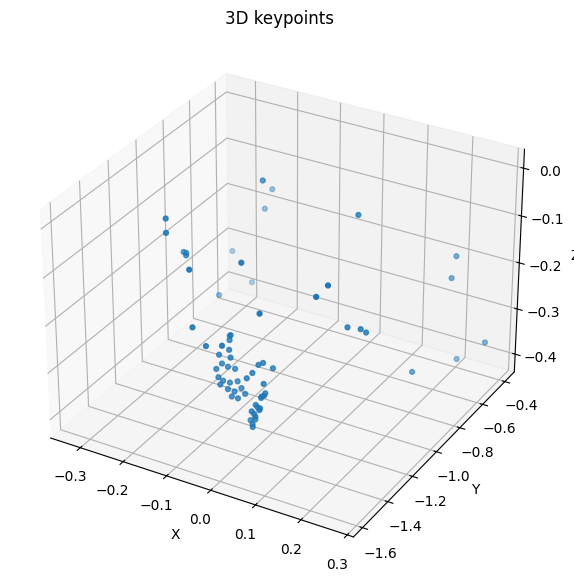

In [25]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

def plot_keypoints_3d(keypoints_3d, title="3D keypoints"):
    pts = np.asarray(keypoints_3d)
    if pts.ndim == 3:
        pts = pts[0]

    fig = plt.figure(figsize=(7, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=12)
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

plot_keypoints_3d(detection["pred_keypoints_3d"])

## Parallel Batch Video Processing

We can now design a function that utilizes the parallel processing capability of the modified library. This method scales effectively across complete video archives.

In [ ]:
def batch_process_video(estimator, video_path, batch_size=16, inference_type="full"):
    """
    Process a video file in parallel batches using SAM-3D-Body.
    
    Args:
        estimator: The initialized SAM3DBodyEstimator.
        video_path: Path to the video file.
        batch_size: Number of frames to process in a single GPU batch.
        inference_type: "full", "body", or "hand".
        
    Returns:
        A list of results where each item is a list of person dicts for that frame.
    """
    import cv2
    import torch
    from tqdm.notebook import tqdm

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return []

    all_results = []
    frames_batch = []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    pbar = tqdm(total=total_frames, desc="Processing Video")

    while True:
        ret, frame = cap.read()
        if not ret:
            if frames_batch:
                # Process remaining frames
                batch_results = estimator.process_batch_parallel(frames_batch, inference_type=inference_type)
                all_results.extend(batch_results)
                pbar.update(len(frames_batch))
            break

        # Convert BGR to RGB for model input
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames_batch.append(frame_rgb)

        if len(frames_batch) == batch_size:
            batch_results = estimator.process_batch_parallel(frames_batch, inference_type=inference_type)
            all_results.extend(batch_results)
            pbar.update(batch_size)
            frames_batch = []

    cap.release()
    pbar.close()
    return all_results

In [ ]:
# Batch process the testing video clip we downloaded above
print(f"Processing video: {video_path}")

# Process with a batch size of 16 (adjust based on GPU VRAM)
batch_results = batch_process_video(estimator, video_path, batch_size=16, inference_type="full")

print(f"\nSuccessfully processed {len(batch_results)} frames.")

if batch_results:
    # Let's inspect the results size layout
    first_frame_stats = batch_results[0]
    if first_frame_stats:
        person = first_frame_stats[0] 
        print("Keys available in output dictionary:\n", list(person.keys()))
        if "pred_keypoints_3d" in person:
            print(f"\nSize of 3D Keypoints to verify: {person['pred_keypoints_3d'].shape}")